In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve
)


In [3]:
df = pd.read_csv("../data/dataset.csv")
df.head()

,Unnamed: 0,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,45840,55822,Female,0,No,No,14,Yes,No,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.05,934.15,No
1,92611,549052,Female,0,No,No,14,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Electronic check,74.95,1145.70,Yes
2,127871,53144,Male,0,Yes,No,30,Yes,Yes,Fiber optic,...,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),104.40,3994.05,Yes
3,107401,579381,Male,0,Yes,No,47,Yes,Yes,Fiber optic,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,88.95,4783.50,No
4,168468,331471,Male,0,No,No,6,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.75,109.65,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        100000 non-null  int64  
 1   id                100000 non-null  int64  
 2   gender            100000 non-null  object 
 3   SeniorCitizen     100000 non-null  int64  
 4   Partner           100000 non-null  object 
 5   Dependents        100000 non-null  object 
 6   tenure            100000 non-null  int64  
 7   PhoneService      100000 non-null  object 
 8   MultipleLines     100000 non-null  object 
 9   InternetService   100000 non-null  object 
 10  OnlineSecurity    100000 non-null  object 
 11  OnlineBackup      100000 non-null  object 
 12  DeviceProtection  100000 non-null  object 
 13  TechSupport       100000 non-null  object 
 14  StreamingTV       100000 non-null  object 
 15  StreamingMovies   100000 non-null  object 
 16  Contract          100

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

Unnamed: 0          0
id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Text(0.5, 1.0, 'Churn Distribution')

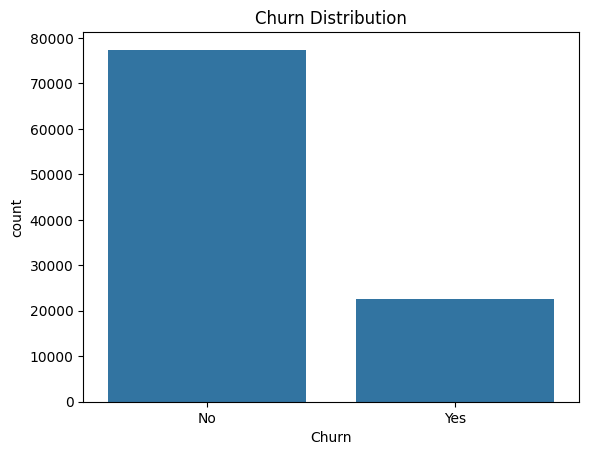

In [8]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")

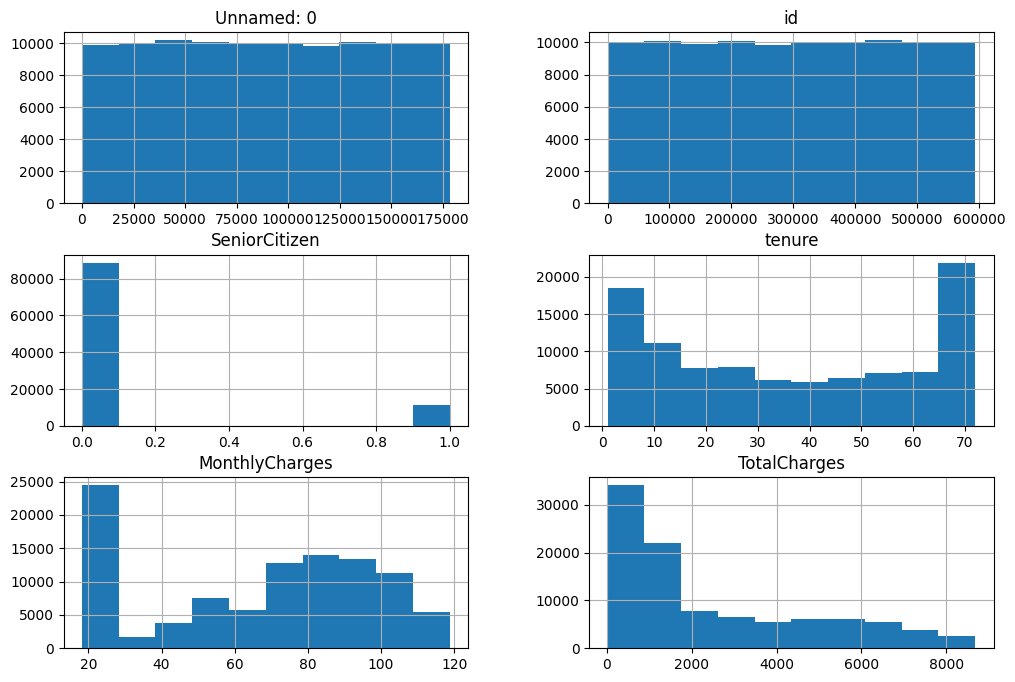

In [9]:
df.hist(figsize=(12, 8))
plt.show()

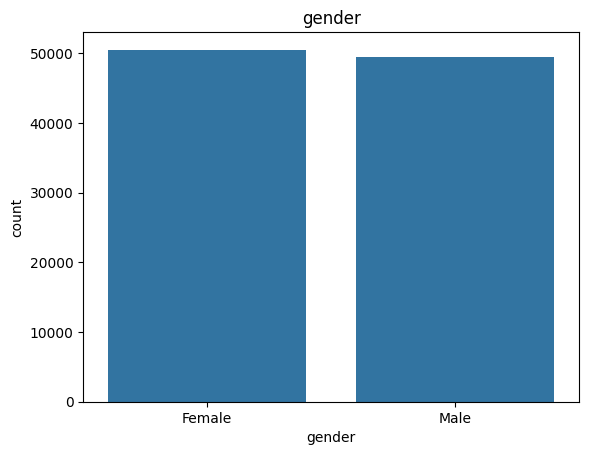

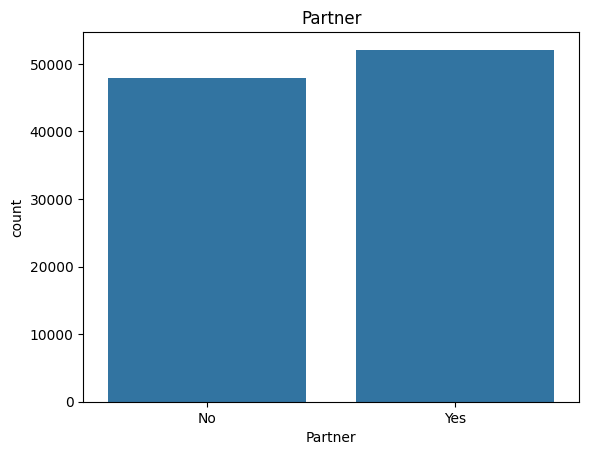

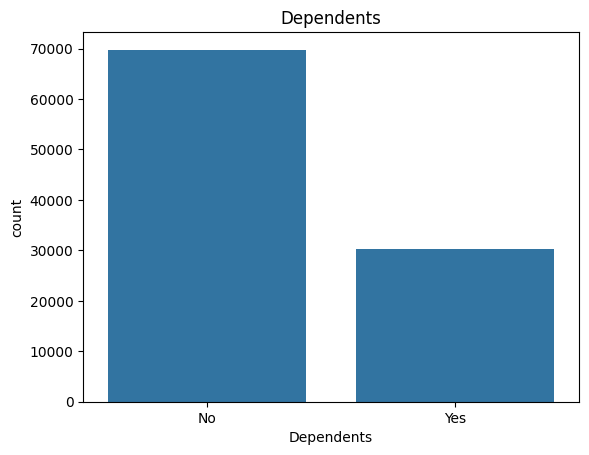

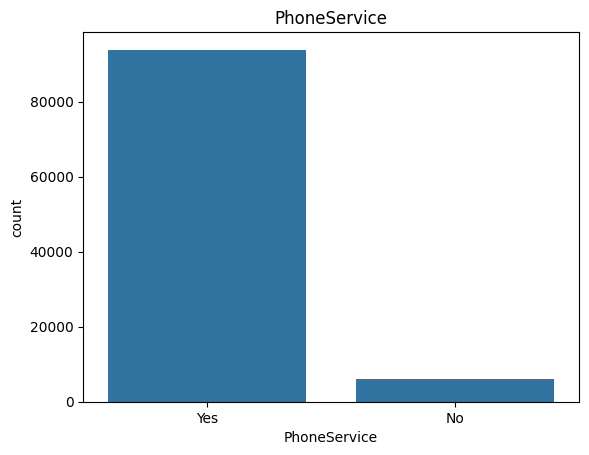

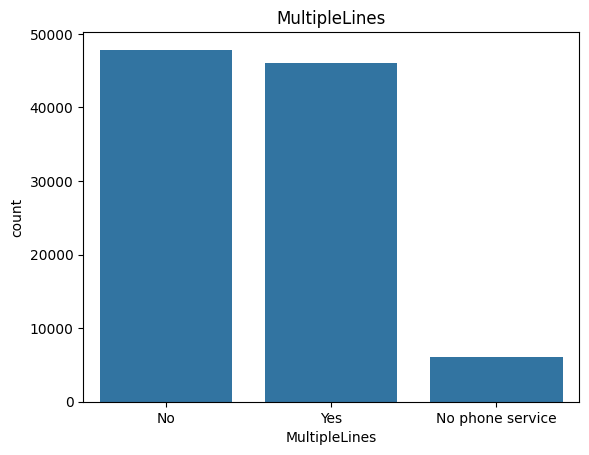

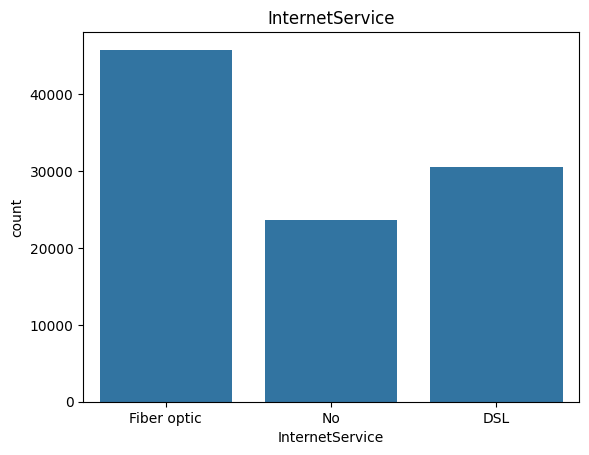

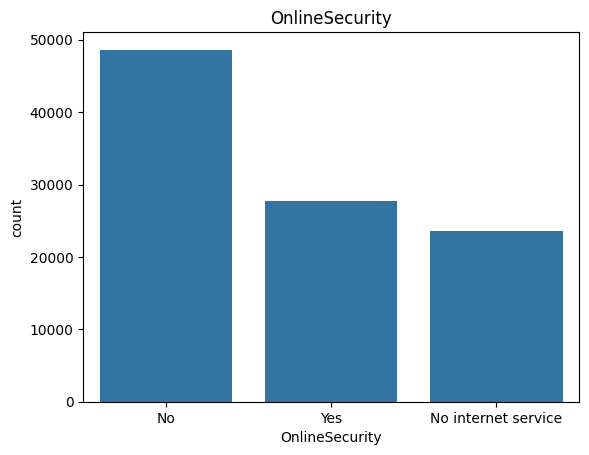

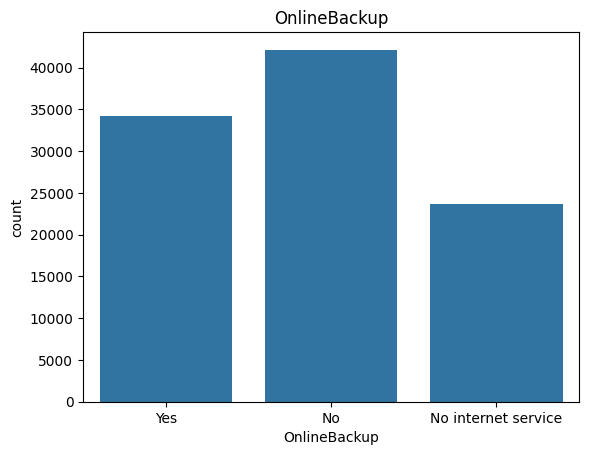

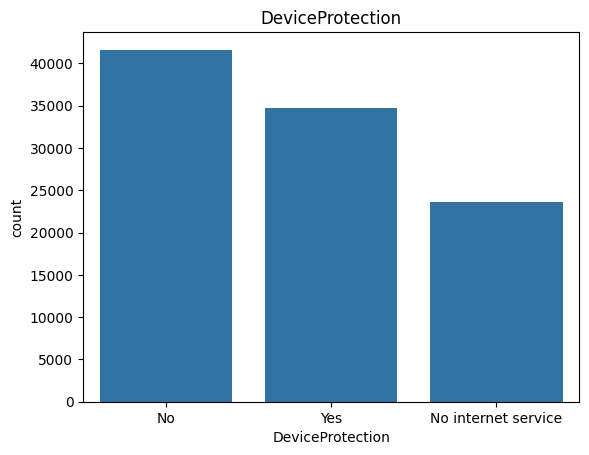

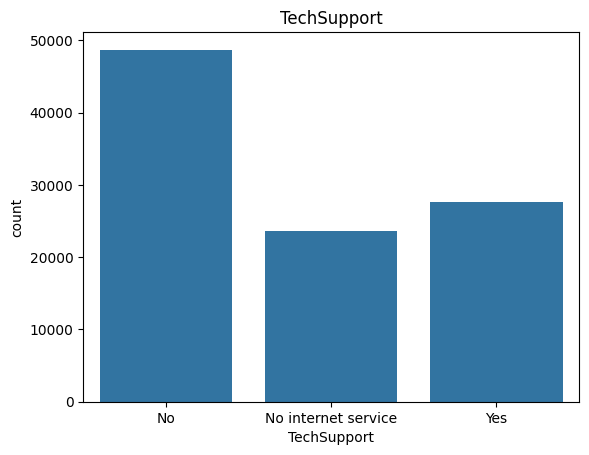

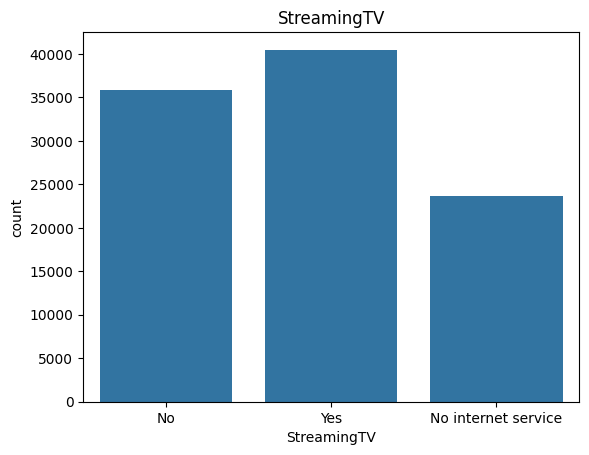

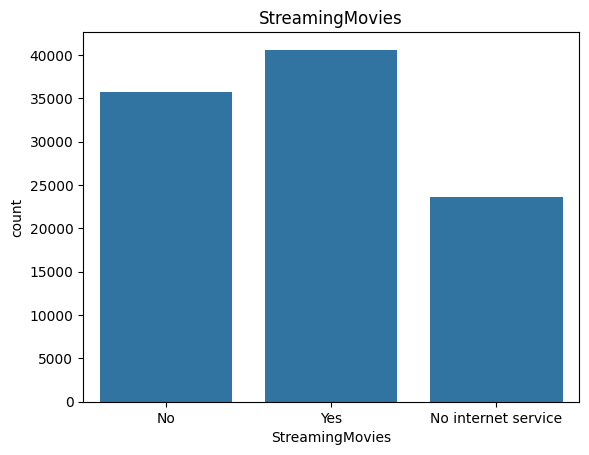

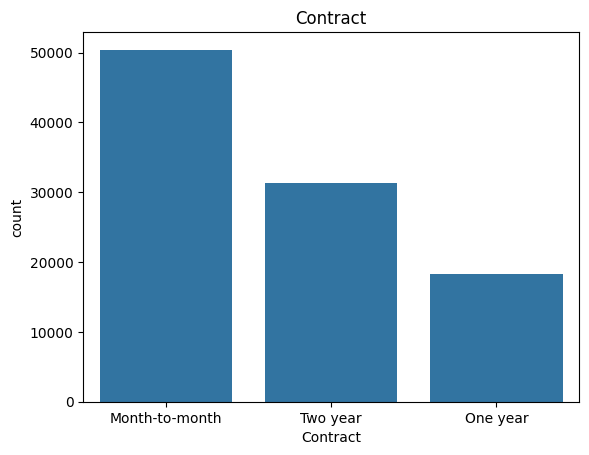

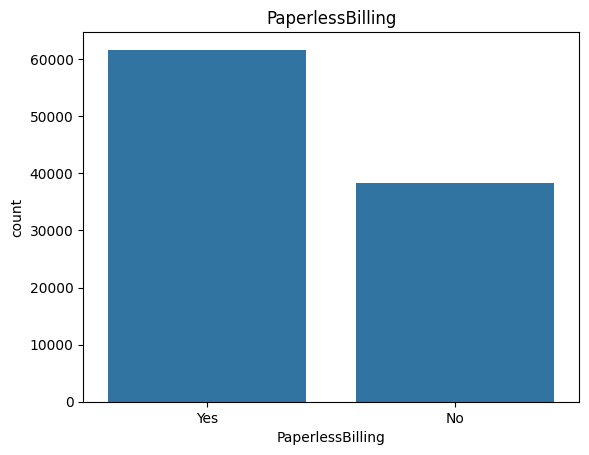

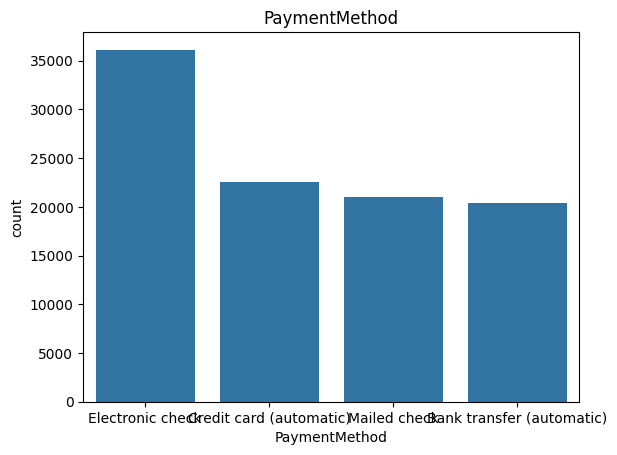

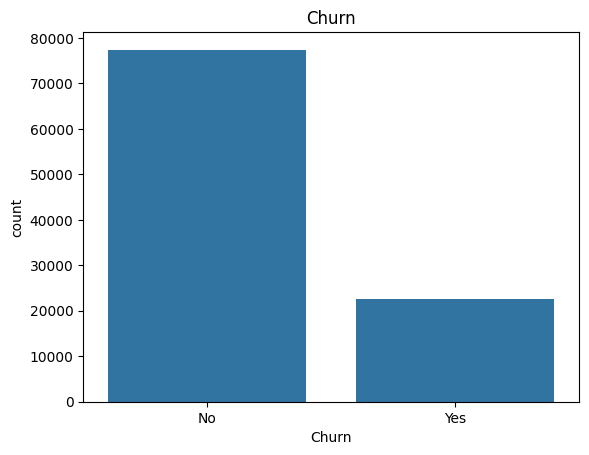

In [10]:
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()

In [11]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["AvgCharges"] = df["TotalCharges"] / (df["tenure"] + 1)

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-1yr", "1-2yr", "2-4yr", "4-6yr"]
)

df["is_long_term"] = np.where(df["tenure"] > 24, 1, 0)

In [12]:
df.sample()

,Unnamed: 0,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgCharges,tenure_group,is_long_term
99700,27001,201909,Male,0,No,No,31,Yes,No,No,...,No internet service,One year,No,Credit card (automatic),20.55,649.65,No,20.301562,2-4yr,1


In [13]:
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"Yes": 1, "No": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
numerical_columns = [
    "tenure", "MonthlyCharges", "TotalCharges",
    "AvgCharges", "is_long_term"
]

categorical_columns = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod",
    "tenure_group"
]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_columns),
    ("cat", cat_pipeline, categorical_columns)
])

In [15]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [16]:
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=400, class_weight="balanced"),
    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=ratio,
        eval_metric="logloss"
    )
}

results = []

for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    y_probs = model.predict_proba(X_test_transformed)[:, 1]
    y_pred = (y_probs >= 0.3).astype(int)

    results.append({
        "model": name,
        "recall": recall_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_probs)
    })

pd.DataFrame(results)

,model,recall,precision,f1,roc_auc
0,LogisticRegression,0.943989,0.477920,0.634571,0.913672
1,RandomForest,0.774408,0.605295,0.679487,0.903542
2,XGBoost,0.943989,0.484986,0.640769,0.918311


In [ ]:
import optuna
def objective(trial):

    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 2.0),
        "scale_pos_weight": ratio,   
        "eval_metric": "logloss",
        "random_state": 42,
        "tree_method": "hist"        
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train_transformed, 
        y_train,
        eval_set=[(X_test_transformed, y_test)],
        early_stopping_rounds=30,
        verbose=False
    )

    preds = model.predict(X_test_transformed)
    f1 = f1_score(y_test, preds)

    return f1


In [21]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

[I 2026-03-18 12:16:23,077] A new study created in memory with name: no-name-ab767951-2a5e-4a7d-b008-a941a55c33ac
d:\krishnaikproj\networksecurity\networkenv\lib\site-packages\xgboost\sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
[I 2026-03-18 12:16:24,821] Trial 0 finished with value: 0.6895421862200782 and parameters: {'max_depth': 8, 'learning_rate': 0.1995547365182567, 'n_estimators': 136, 'subsample': 0.628418633876635, 'colsample_bytree': 0.7094174501541272, 'gamma': 0.4482242341527976, 'reg_lambda': 2.7128517981675886, 'reg_alpha': 0.2687299876210518}. Best is trial 0 with value: 0.6895421862200782.
d:\krishnaikproj\networksecurity\networkenv\lib\site-packages\xgboost\sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_roun

In [22]:
best_params = study.best_params
best_params



{'max_depth': 7,
 'learning_rate': 0.05054466895597165,
 'n_estimators': 494,
 'subsample': 0.9222145292239797,
 'colsample_bytree': 0.8701105285396024,
 'gamma': 0.16300528551755963,
 'reg_lambda': 2.261702105270148,
 'reg_alpha': 1.9273816034982025}

In [23]:
best_xgb = XGBClassifier(
    **best_params,
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42
)

best_xgb.fit(
    X_train_transformed,
    y_train,
    eval_set=[(X_test_transformed, y_test)],
    early_stopping_rounds=30,
    verbose=False
)

d:\krishnaikproj\networksecurity\networkenv\lib\site-packages\xgboost\sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


,objective,'binary:logistic'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8701105285396024
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [24]:
from sklearn.metrics import classification_report

preds = best_xgb.predict(X_test_transformed)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.95      0.82      0.88     15483
           1       0.58      0.85      0.69      4517

    accuracy                           0.83     20000
   macro avg       0.76      0.84      0.78     20000
weighted avg       0.87      0.83      0.84     20000

